# 01 - Entrenamiento inicial de sentimiento sobre reviews gastronómicas

## Objetivo del notebook

Este notebook inicia la fase de IA/NLP de Hidden Gems entrenando y evaluando modelos de sentimiento general sobre reseñas gastronómicas del Yelp Open Dataset.

Este modelo no representa todavía el sentimiento final por plato, sino un primer módulo auxiliar para:

- validar el entorno de entrenamiento;
- trabajar con un corpus gastronómico real;
- comparar modelos clásicos y modelos modernos de NLP;
- analizar las limitaciones de usar ratings como etiquetas débiles de sentimiento;
- preparar la base metodológica para módulos posteriores:
  - detección de platos;
  - normalización de platos;
  - sentimiento por mención;
  - ranking explicable.

## Enfoque

La etiqueta de sentimiento se deriva del rating:

- 1-2 estrellas: negative
- 3 estrellas: neutral
- 4-5 estrellas: positive

Esta etiqueta se considera una etiqueta débil (*weak label*), ya que una reseña puede contener opiniones mixtas sobre comida, servicio, precio o ambiente.

In [2]:
# ============================================================
# 01. Instalación de dependencias
# ============================================================

!pip -q install pandas numpy scikit-learn matplotlib tqdm
!pip -q install datasets transformers evaluate accelerate

In [3]:
# ============================================================
# 02. Imports y configuración base
# ============================================================

from pathlib import Path
import json
import random
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 250)

print("Entorno inicializado correctamente.")

Entorno inicializado correctamente.


In [10]:
# ============================================================
# 03. Montar Google Drive de forma robusta
# ============================================================

from pathlib import Path

USE_DRIVE = True

if USE_DRIVE:
    try:
        from google.colab import drive

        # Limpieza preventiva del punto de montaje
        !fusermount -u /content/drive 2>/dev/null || true
        !rm -rf /content/drive

        drive.mount("/content/drive", force_remount=True, timeout_ms=120000)

        PROJECT_DIR = Path("/content/drive/MyDrive/hidden_gems_ai")
        DATA_DIR = PROJECT_DIR / "data"

        PROJECT_DIR.mkdir(parents=True, exist_ok=True)
        DATA_DIR.mkdir(parents=True, exist_ok=True)

        print("Google Drive montado correctamente.")
        print("PROJECT_DIR:", PROJECT_DIR)
        print("DATA_DIR:", DATA_DIR)

    except Exception as e:
        print("No se ha podido montar Google Drive.")
        print("Error:", e)
        print("Se usará almacenamiento temporal de Colab en /content/hidden_gems_ai")

        USE_DRIVE = False
        PROJECT_DIR = Path("/content/hidden_gems_ai")
        DATA_DIR = PROJECT_DIR / "data"

        PROJECT_DIR.mkdir(parents=True, exist_ok=True)
        DATA_DIR.mkdir(parents=True, exist_ok=True)


else:
    PROJECT_DIR = Path("/content/hidden_gems_ai")
    DATA_DIR = PROJECT_DIR / "data"

    PROJECT_DIR.mkdir(parents=True, exist_ok=True)
    DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Ruta activa del proyecto:", PROJECT_DIR)
print("Ruta activa de datos:", DATA_DIR)

No se ha podido montar Google Drive.
Error: mount failed
Se usará almacenamiento temporal de Colab en /content/hidden_gems_ai
Ruta activa del proyecto: /content/hidden_gems_ai
Ruta activa de datos: /content/hidden_gems_ai/data


## Archivos esperados

Para este notebook se recomienda trabajar con el corpus NLP final generado por la vertical Yelp:

`yelp_food_reviews_corpus_sample_100k_lines.jsonl`

Si ese archivo no está disponible, también puede utilizarse:

`food_reviews.jsonl`

El notebook intentará detectar automáticamente la estructura del archivo y preparar el dataset de entrenamiento.

In [12]:
# ============================================================
# 04. Configurar ruta del dataset
# ============================================================

# Opción recomendada:
CORPUS_PATH = DATA_DIR / "yelp_food_reviews_corpus_sample_100k_lines.jsonl"

# Fallback si aún no has copiado el corpus final:
FOOD_REVIEWS_PATH = DATA_DIR / "food_reviews.jsonl"

if CORPUS_PATH.exists():
    DATASET_PATH = CORPUS_PATH
elif FOOD_REVIEWS_PATH.exists():
    DATASET_PATH = FOOD_REVIEWS_PATH
else:
    raise FileNotFoundError(
        "No se ha encontrado ningún archivo de datos.\n"
        f"Coloca uno de estos archivos en {DATA_DIR}:\n"
        f"- {CORPUS_PATH.name}\n"
        f"- {FOOD_REVIEWS_PATH.name}"
    )

print("Archivo seleccionado:")
print(DATASET_PATH)

Archivo seleccionado:
/content/hidden_gems_ai/data/yelp_food_reviews_corpus_sample_100k_lines.jsonl


In [13]:
# ============================================================
# 05. Cargar archivo JSONL
# ============================================================

def load_jsonl(path: Path) -> pd.DataFrame:
    records = []
    invalid_lines = 0

    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(tqdm(f, desc="Leyendo JSONL"), start=1):
            line = line.strip()
            if not line:
                continue

            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                invalid_lines += 1

    print(f"Registros cargados: {len(records):,}")
    print(f"Líneas JSON inválidas: {invalid_lines:,}")

    return pd.DataFrame(records)


df_raw = load_jsonl(DATASET_PATH)

print("Shape inicial:", df_raw.shape)
display(df_raw.head(3))

Leyendo JSONL: 0it [00:00, ?it/s]

Registros cargados: 79,270
Líneas JSON inválidas: 0
Shape inicial: (79270, 20)


,corpus_document_id,source_system_code,source_dataset,source_entity_type,source_review_id,source_business_id,source_user_id,text,text_normalized,language,rating_value,sentiment_label_from_rating,review_date,corpus_split,task_scope,is_training_eligible,quality_flags,business_metadata,source_metrics,created_at
0,yelp_2fbfd094613536a7b8c9231b,yelp_open_dataset,yelp_open_dataset,yelp_review,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,mh_-eMZ6K5RLWhZyISBhwA,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is go...","If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is go...",en,3.0,neutral,2018-07-07 22:09:11,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 511, 'label_is_weak': True, 'label_source': 'rating_value'}","{'business_name': 'Turning Point of North Wales', 'city': 'North Wales', 'state': 'PA', 'stars_business': 3.0, 'review_count_business': 169, 'is_open': 1, 'categories_list': ['Restaurants', 'Breakfast & Brunch', 'Food', 'Juice Bars & Smoothies', ...","{'useful_count': 0, 'funny_count': 0, 'cool_count': 0}",2026-05-06T10:57:56.623430+00:00
1,yelp_94c5a64cecd4448d105e5c8a,yelp_open_dataset,yelp_open_dataset,yelp_review,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,8g_iMtfSiwikVnbP2etR0A,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive...","Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive...",en,3.0,neutral,2014-02-05 20:30:30,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 339, 'label_is_weak': True, 'label_source': 'rating_value'}","{'business_name': 'Kettle Restaurant', 'city': 'Tucson', 'state': 'AZ', 'stars_business': 3.5, 'review_count_business': 47, 'is_open': 1, 'categories_list': ['Restaurants', 'Breakfast & Brunch'], 'food_category_tags': ['Breakfast & Brunch', 'Rest...","{'useful_count': 0, 'funny_count': 0, 'cool_count': 0}",2026-05-06T10:57:56.624430+00:00
2,yelp_69e10d25d69774ab39af6571,yelp_open_dataset,yelp_open_dataset,yelp_review,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,_7bHUi9Uuf5__HHc_Q8guQ,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!","Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",en,5.0,positive,2015-01-04 00:01:03,train,"[dish_extraction, review_sentiment, dish_sentiment, recommendation_signal]",True,"{'has_text': True, 'has_rating': True, 'has_business_metadata': True, 'text_length_chars': 235, 'label_is_weak': True, 'label_source': 'rating_value'}","{'business_name': 'Zaika', 'city': 'Philadelphia', 'state': 'PA', 'stars_business': 4.0, 'review_count_business': 181, 'is_open': 1, 'categories_list': ['Halal', 'Pakistani', 'Restaurants', 'Indian'], 'food_category_tags': ['Indian', 'Restaurant

In [14]:
# ============================================================
# 06. Inspección inicial de columnas
# ============================================================

print("Columnas disponibles:")
for col in df_raw.columns:
    print("-", col)

print("\nTipos de datos:")
display(df_raw.dtypes)

print("\nNulos por columna:")
display(df_raw.isna().sum().sort_values(ascending=False).head(30))

Columnas disponibles:
- corpus_document_id
- source_system_code
- source_dataset
- source_entity_type
- source_review_id
- source_business_id
- source_user_id
- text
- text_normalized
- language
- rating_value
- sentiment_label_from_rating
- review_date
- corpus_split
- task_scope
- is_training_eligible
- quality_flags
- business_metadata
- source_metrics
- created_at

Tipos de datos:


,0
corpus_document_id,object
source_system_code,object
source_dataset,object
source_entity_type,object
source_review_id,object
source_business_id,object
source_user_id,object
text,object
text_normalized,object
language,object



Nulos por columna:


,0
corpus_document_id,0
source_system_code,0
source_dataset,0
source_entity_type,0
source_review_id,0
source_business_id,0
source_user_id,0
text,0
text_normalized,0
language,0


In [15]:
# ============================================================
# 07. Detección automática de columnas clave
# ============================================================

def find_first_existing_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    return None


TEXT_COL = find_first_existing_column(
    df_raw,
    [
        "text",
        "review_text",
        "review_text_raw",
        "text_raw",
        "review"
    ]
)

RATING_COL = find_first_existing_column(
    df_raw,
    [
        "rating_value",
        "stars",
        "review_stars"
    ]
)

LABEL_COL = find_first_existing_column(
    df_raw,
    [
        "sentiment_label_from_rating",
        "sentiment_label",
        "label"
    ]
)

SPLIT_COL = find_first_existing_column(
    df_raw,
    [
        "corpus_split",
        "split"
    ]
)

REVIEW_ID_COL = find_first_existing_column(
    df_raw,
    [
        "source_review_id",
        "review_id"
    ]
)

BUSINESS_ID_COL = find_first_existing_column(
    df_raw,
    [
        "source_business_id",
        "business_id"
    ]
)

print("Columnas detectadas:")
print("TEXT_COL:", TEXT_COL)
print("RATING_COL:", RATING_COL)
print("LABEL_COL:", LABEL_COL)
print("SPLIT_COL:", SPLIT_COL)
print("REVIEW_ID_COL:", REVIEW_ID_COL)
print("BUSINESS_ID_COL:", BUSINESS_ID_COL)

if TEXT_COL is None:
    raise ValueError("No se ha podido detectar una columna de texto.")

if RATING_COL is None and LABEL_COL is None:
    raise ValueError("No se ha podido detectar ni rating ni etiqueta de sentimiento.")

Columnas detectadas:
TEXT_COL: text
RATING_COL: rating_value
LABEL_COL: sentiment_label_from_rating
SPLIT_COL: corpus_split
REVIEW_ID_COL: source_review_id
BUSINESS_ID_COL: source_business_id


In [16]:
# ============================================================
# 08. Preparar dataset normalizado
# ============================================================

df = df_raw.copy()

# Texto
df["text"] = df[TEXT_COL].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

# Rating
if RATING_COL is not None:
    df["rating_value"] = pd.to_numeric(df[RATING_COL], errors="coerce")
else:
    df["rating_value"] = np.nan

# Etiqueta de sentimiento
def rating_to_sentiment(rating):
    if pd.isna(rating):
        return None
    if rating <= 2:
        return "negative"
    if rating == 3:
        return "neutral"
    if rating >= 4:
        return "positive"
    return None


if LABEL_COL is not None:
    df["sentiment_label"] = df[LABEL_COL].astype(str).str.lower().str.strip()
else:
    df["sentiment_label"] = df["rating_value"].apply(rating_to_sentiment)

# IDs
if REVIEW_ID_COL is not None:
    df["review_id"] = df[REVIEW_ID_COL].astype(str)
else:
    df["review_id"] = [
        hashlib.sha256(text.encode("utf-8")).hexdigest()[:24]
        for text in df["text"]
    ]

if BUSINESS_ID_COL is not None:
    df["business_id"] = df[BUSINESS_ID_COL].astype(str)
else:
    df["business_id"] = "unknown"

# Longitud
df["text_length_chars"] = df["text"].str.len()

# Nos quedamos con campos útiles para entrenamiento
keep_cols = [
    "review_id",
    "business_id",
    "text",
    "text_length_chars",
    "rating_value",
    "sentiment_label"
]

# Añadir metadata si existe
for optional_col in ["business_name", "city", "state", "language", "review_date", "date", "food_category_tags"]:
    if optional_col in df.columns and optional_col not in keep_cols:
        keep_cols.append(optional_col)

df = df[keep_cols].copy()

# Limpieza básica
valid_labels = {"positive", "neutral", "negative"}

before_count = len(df)

df = df[
    df["text"].notna()
    & (df["text"].str.len() > 0)
    & df["sentiment_label"].isin(valid_labels)
].copy()

after_count = len(df)

print(f"Registros antes de limpieza: {before_count:,}")
print(f"Registros después de limpieza: {after_count:,}")
print(f"Registros descartados: {before_count - after_count:,}")

display(df.head(5))

Registros antes de limpieza: 79,270
Registros después de limpieza: 79,270
Registros descartados: 0


,review_id,business_id,text,text_length_chars,rating_value,sentiment_label,language,review_date
0,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,"If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ and never had a bad experience. The food is go...",511,3.0,neutral,en,2018-07-07 22:09:11
1,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,"Family diner. Had the buffet. Eclectic assortment: a large chicken leg, fried jalapeño, tamale, two rolled grape leaves, fresh melon. All good. Lots of Mexican choices there. Also has a menu with breakfast served all day long. Friendly, attentive...",339,3.0,neutral,en,2014-02-05 20:30:30
2,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,"Wow! Yummy, different, delicious. Our favorite is the lamb curry and korma. With 10 different kinds of naan!!! Don't let the outside deter you (because we almost changed our minds)...go in and try something new! You'll be glad you did!",235,5.0,positive,en,2015-01-04 00:01:03
3,Sx8TMOWLNuJBWer-0pcmoA,e4Vwtrqf-wpJfwesgvdgxQ,"Cute interior and owner (?) gave us tour of upcoming patio/rooftop area which will be great on beautiful days like today. Cheese curds were very good and very filling. Really like that sandwiches come w salad, esp after eating too many curds! Had...",534,4.0,positive,en,2017-01-14 20:54:15
4,JrIxlS1TzJ-iCu79ul40cQ,04UD14gamNjLY0IDYVhHJg,I am a long term frequent customer of this establishment. I just went in to order take out (3 apps) and was told they're too busy to do it. Really? The place is maybe half full at best. Does your dick reach your ass? Yes? Go fuck yourself! I'm a ...,341,1.0,negative,en,2015-09-23 23:10:31


In [17]:
# ============================================================
# 09. Crear o validar split train/validation/test
# ============================================================

if SPLIT_COL is not None and SPLIT_COL in df_raw.columns:
    # Recuperar split original alineando por review_id si existe
    split_source = df_raw.copy()

    if REVIEW_ID_COL is not None:
        split_source["review_id"] = split_source[REVIEW_ID_COL].astype(str)
        split_map = split_source.set_index("review_id")[SPLIT_COL].to_dict()
        df["split"] = df["review_id"].map(split_map)
    else:
        df["split"] = split_source[SPLIT_COL].values[:len(df)]

    df["split"] = df["split"].astype(str).str.lower().str.strip()

    valid_splits = {"train", "validation", "test"}
    if not set(df["split"].dropna().unique()).issubset(valid_splits):
        print("El split existente contiene valores no esperados. Se generará un split nuevo.")
        SPLIT_COL = None

if SPLIT_COL is None or "split" not in df.columns or df["split"].isna().any():
    print("Generando split estratificado nuevo...")

    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=df["sentiment_label"]
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=RANDOM_STATE,
        stratify=temp_df["sentiment_label"]
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["split"] = "train"
    val_df["split"] = "validation"
    test_df["split"] = "test"

    df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Distribución de splits:")
display(df["split"].value_counts())

print("\nDistribución label x split:")
display(pd.crosstab(df["split"], df["sentiment_label"]))

Distribución de splits:


,count
split,
train,63540
test,7881
validation,7849



Distribución label x split:


sentiment_label,negative,neutral,positive
split,,,
test,1428,936,5517
train,11701,7894,43945
validation,1449,1005,5395


In [18]:
# ============================================================
# 10. Comprobaciones de calidad del dataset
# ============================================================

checks = {
    "has_rows": len(df) > 0,
    "has_text": df["text"].notna().all(),
    "has_labels": df["sentiment_label"].isin(valid_labels).all(),
    "has_train": (df["split"] == "train").any(),
    "has_validation": (df["split"] == "validation").any(),
    "has_test": (df["split"] == "test").any(),
    "review_ids_unique": df["review_id"].is_unique,
    "no_empty_text": (df["text"].str.len() > 0).all(),
}

for check_name, check_value in checks.items():
    print(f"{check_name}: {check_value}")

if not all(checks.values()):
    raise ValueError("Alguna comprobación crítica del dataset ha fallado.")

print("\nDataset validado correctamente.")

has_rows: True
has_text: True
has_labels: True
has_train: True
has_validation: True
has_test: True
review_ids_unique: True
no_empty_text: True

Dataset validado correctamente.


,count,percentage
sentiment_label,,
positive,54857,69.20
negative,14578,18.39
neutral,9835,12.41


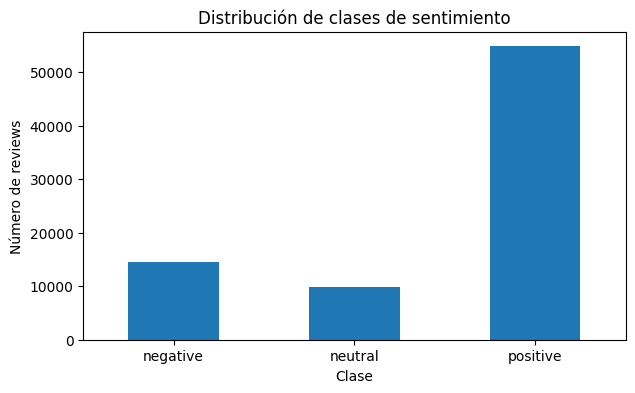

In [19]:
# ============================================================
# 11. Distribución de clases
# ============================================================

label_counts = df["sentiment_label"].value_counts()
label_percentages = df["sentiment_label"].value_counts(normalize=True).mul(100).round(2)

label_summary = pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages
})

display(label_summary)

plt.figure(figsize=(7, 4))
label_counts.loc[["negative", "neutral", "positive"]].plot(kind="bar")
plt.title("Distribución de clases de sentimiento")
plt.xlabel("Clase")
plt.ylabel("Número de reviews")
plt.xticks(rotation=0)
plt.show()

,text_length_chars
count,79270.000000
mean,534.756818
std,487.986901
min,80.000000
25%,220.000000
50%,383.000000
75%,674.000000
max,4999.000000


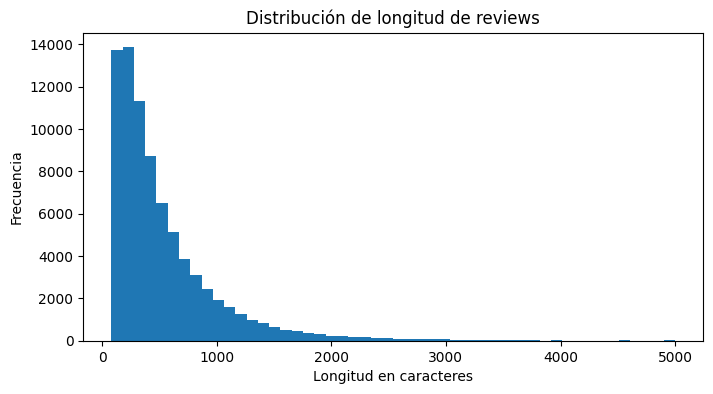

Longitud media por clase:


,count,mean,median,min,max
sentiment_label,,,,,
negative,14578,646.56,476.0,80,4978
neutral,9835,637.49,475.0,80,4952
positive,54857,486.63,347.0,80,4999


In [20]:
# ============================================================
# 12. Análisis de longitud de textos
# ============================================================

display(df["text_length_chars"].describe())

plt.figure(figsize=(8, 4))
df["text_length_chars"].plot(kind="hist", bins=50)
plt.title("Distribución de longitud de reviews")
plt.xlabel("Longitud en caracteres")
plt.ylabel("Frecuencia")
plt.show()

print("Longitud media por clase:")
display(
    df.groupby("sentiment_label")["text_length_chars"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

In [21]:
# ============================================================
# 13. Ejemplos por clase
# ============================================================

def show_examples_by_label(df: pd.DataFrame, label: str, n: int = 5):
    print("=" * 100)
    print(f"EJEMPLOS DE CLASE: {label.upper()}")
    print("=" * 100)

    sample_df = df[df["sentiment_label"] == label].sample(
        n=min(n, (df["sentiment_label"] == label).sum()),
        random_state=RANDOM_STATE
    )

    for i, row in enumerate(sample_df.itertuples(), start=1):
        print(f"\nEjemplo {i}")
        print(f"Rating: {getattr(row, 'rating_value', None)}")
        print(f"Business ID: {getattr(row, 'business_id', None)}")
        print(f"Texto:\n{row.text[:1000]}")
        print("-" * 100)


for label in ["negative", "neutral", "positive"]:
    show_examples_by_label(df, label, n=3)

EJEMPLOS DE CLASE: NEGATIVE

Ejemplo 1
Rating: 1.0
Business ID: B2wSy1zQCdZgDXOkhAKGDQ
Texto:
Not the best check in. It took forever. For the price they charge maybe they should keep the rooms a little better. For top dollar I expect a little better.
----------------------------------------------------------------------------------------------------

Ejemplo 2
Rating: 1.0
Business ID: sxuv5uZU15UHGT_HB1xYxQ
Texto:
Went in for lunch today with my husband and ordered two burgers medium rare- husbands burger came out perfect but mine was medium well. I was talking and didn't realize it until I was on the second half of my burger( literally had half a burger left) and showed the waitress each burger and said it was ok but to let the manager know that they need to make sure the burgers are getting cooked to order. She said ok and left. Then some girl who looked barely 18 walked up and asked what the problem was. I let her know about the burgers and she had the nerve to tell me that "next ti

In [22]:
# ============================================================
# 14. Revisión de solapamiento de negocios entre splits
# ============================================================

business_by_split = {
    split: set(df.loc[df["split"] == split, "business_id"])
    for split in ["train", "validation", "test"]
}

overlap_train_val = business_by_split["train"] & business_by_split["validation"]
overlap_train_test = business_by_split["train"] & business_by_split["test"]
overlap_val_test = business_by_split["validation"] & business_by_split["test"]

print("Negocios únicos por split:")
for split, business_set in business_by_split.items():
    print(split, len(business_set))

print("\nSolapamientos de business_id:")
print("train ∩ validation:", len(overlap_train_val))
print("train ∩ test:", len(overlap_train_test))
print("validation ∩ test:", len(overlap_val_test))

print(
    "\nNota: para sentimiento general no es necesariamente crítico, "
    "pero conviene documentarlo. Para evaluación más estricta, "
    "más adelante podríamos hacer split por business_id."
)

Negocios únicos por split:
train 4960
validation 2593
test 2587

Solapamientos de business_id:
train ∩ validation: 2491
train ∩ test: 2488
validation ∩ test: 1746

Nota: para sentimiento general no es necesariamente crítico, pero conviene documentarlo. Para evaluación más estricta, más adelante podríamos hacer split por business_id.


In [24]:
# ============================================================
# 15. Guardar dataset preparado
# ============================================================

OUTPUT_DIR = PROJECT_DIR / "outputs" / "sentiment_review"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

prepared_path = OUTPUT_DIR / "yelp_sentiment_prepared_dataset.parquet"
summary_path = OUTPUT_DIR / "yelp_sentiment_dataset_summary.json"

# Guardar dataset preparado
df.to_parquet(prepared_path, index=False)

# Convertir checks a bool nativo de Python para evitar errores JSON
checks_serializable = {
    key: bool(value)
    for key, value in checks.items()
}

summary = {
    "total_documents": int(len(df)),
    "split_counts": {
        str(key): int(value)
        for key, value in df["split"].value_counts().to_dict().items()
    },
    "label_counts": {
        str(key): int(value)
        for key, value in df["sentiment_label"].value_counts().to_dict().items()
    },
    "text_length": {
        "min": int(df["text_length_chars"].min()),
        "max": int(df["text_length_chars"].max()),
        "mean": float(df["text_length_chars"].mean()),
        "median": float(df["text_length_chars"].median()),
    },
    "checks": checks_serializable,
}

with summary_path.open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Dataset preparado guardado en:")
print(prepared_path)

print("\nResumen guardado en:")
print(summary_path)

print("\nResumen:")
print(json.dumps(summary, indent=2, ensure_ascii=False))

Dataset preparado guardado en:
/content/hidden_gems_ai/outputs/sentiment_review/yelp_sentiment_prepared_dataset.parquet

Resumen guardado en:
/content/hidden_gems_ai/outputs/sentiment_review/yelp_sentiment_dataset_summary.json

Resumen:
{
  "total_documents": 79270,
  "split_counts": {
    "train": 63540,
    "test": 7881,
    "validation": 7849
  },
  "label_counts": {
    "positive": 54857,
    "negative": 14578,
    "neutral": 9835
  },
  "text_length": {
    "min": 80,
    "max": 4999,
    "mean": 534.7568184685252,
    "median": 383.0
  },
  "checks": {
    "has_rows": true,
    "has_text": true,
    "has_labels": true,
    "has_train": true,
    "has_validation": true,
    "has_test": true,
    "review_ids_unique": true,
    "no_empty_text": true
  }
}



## 2. Baselines y modelo clásico

Antes de entrenar modelos avanzados, se construyen varios modelos base para tener una referencia objetiva:

1. **Baseline mayoritario**: predice siempre la clase más frecuente.
2. **TF-IDF + Regresión Logística**: modelo clásico de NLP supervisado.
3. **TF-IDF + Regresión Logística balanceada**: variante que compensa el desbalance de clases.

El objetivo de este bloque no es obtener todavía el modelo definitivo, sino establecer una línea base sólida y medible antes de pasar a transformers.


In [25]:
# ============================================================
# 16. Preparar train, validation y test
# ============================================================

# Usamos text_normalized si existe en el dataframe original.
# Si no, usamos la columna text ya preparada.
if "text_normalized" in df_raw.columns:
    text_map = df_raw.set_index("source_review_id")["text_normalized"].to_dict()
    df["model_text"] = df["review_id"].map(text_map).fillna(df["text"])
else:
    df["model_text"] = df["text"]

# Asegurar texto limpio
df["model_text"] = (
    df["model_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "validation"].copy()
test_df = df[df["split"] == "test"].copy()

X_train = train_df["model_text"]
y_train = train_df["sentiment_label"]

X_val = val_df["model_text"]
y_val = val_df["sentiment_label"]

X_test = test_df["model_text"]
y_test = test_df["sentiment_label"]

label_order = ["negative", "neutral", "positive"]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nDistribución train:")
display(y_train.value_counts())

print("\nDistribución validation:")
display(y_val.value_counts())

print("\nDistribución test:")
display(y_test.value_counts())

Train: (63540,) (63540,)
Validation: (7849,) (7849,)
Test: (7881,) (7881,)

Distribución train:


,count
sentiment_label,
positive,43945
negative,11701
neutral,7894



Distribución validation:


,count
sentiment_label,
positive,5395
negative,1449
neutral,1005



Distribución test:


,count
sentiment_label,
positive,5517
negative,1428
neutral,936


In [26]:
# ============================================================
# 17. Funciones de evaluación
# ============================================================

def evaluate_predictions(y_true, y_pred, model_name: str, split_name: str):
    """
    Calcula métricas principales para clasificación multiclase.
    """

    metrics = {
        "model_name": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    print("=" * 80)
    print(f"{model_name} - {split_name}")
    print("=" * 80)
    print(f"Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Macro F1:    {metrics['macro_f1']:.4f}")
    print(f"Weighted F1: {metrics['weighted_f1']:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=label_order,
            target_names=label_order,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred, labels=label_order)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Matriz de confusión - {model_name} - {split_name}")
    plt.show()

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=label_order,
        target_names=label_order,
        output_dict=True,
        zero_division=0
    )

    return metrics, report_dict, cm.tolist()

Majority Baseline - validation
Accuracy:    0.6873
Macro F1:    0.2716
Weighted F1: 0.5600

Classification report:
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000      1449
     neutral     0.0000    0.0000    0.0000      1005
    positive     0.6873    1.0000    0.8147      5395

    accuracy                         0.6873      7849
   macro avg     0.2291    0.3333    0.2716      7849
weighted avg     0.4724    0.6873    0.5600      7849



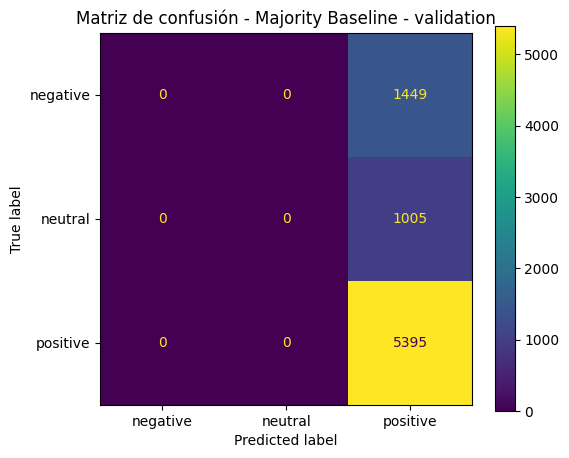

Majority Baseline - test
Accuracy:    0.7000
Macro F1:    0.2745
Weighted F1: 0.5765

Classification report:
              precision    recall  f1-score   support

    negative     0.0000    0.0000    0.0000      1428
     neutral     0.0000    0.0000    0.0000       936
    positive     0.7000    1.0000    0.8236      5517

    accuracy                         0.7000      7881
   macro avg     0.2333    0.3333    0.2745      7881
weighted avg     0.4901    0.7000    0.5765      7881



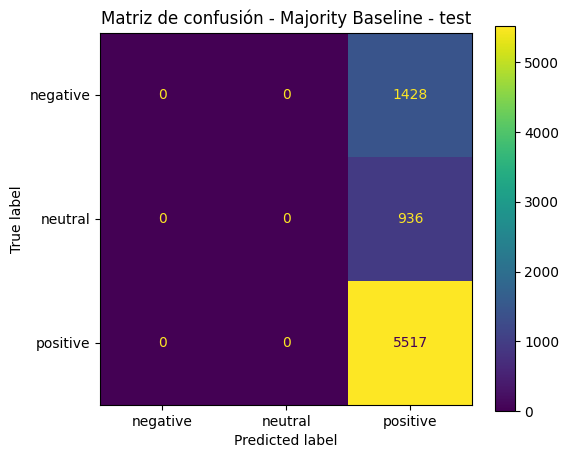

In [27]:
# ============================================================
# 18. Baseline mayoritario
# ============================================================

from sklearn.dummy import DummyClassifier

majority_baseline = DummyClassifier(strategy="most_frequent")

majority_baseline.fit(X_train, y_train)

val_pred_majority = majority_baseline.predict(X_val)
test_pred_majority = majority_baseline.predict(X_test)

majority_val_metrics, majority_val_report, majority_val_cm = evaluate_predictions(
    y_val,
    val_pred_majority,
    model_name="Majority Baseline",
    split_name="validation"
)

majority_test_metrics, majority_test_report, majority_test_cm = evaluate_predictions(
    y_test,
    test_pred_majority,
    model_name="Majority Baseline",
    split_name="test"
)

### Interpretación esperada del baseline mayoritario

Este baseline predice siempre la clase más frecuente, que en este corpus es `positive`.

Por eso puede obtener una accuracy aparentemente alta, cercana al porcentaje de reseñas positivas, pero su rendimiento real será pobre en `macro_f1`, ya que no detecta correctamente las clases `negative` ni `neutral`.

Este baseline sirve como referencia mínima: cualquier modelo útil debe superar claramente este resultado, especialmente en macro F1.

TF-IDF + Logistic Regression - validation
Accuracy:    0.8629
Macro F1:    0.7269
Weighted F1: 0.8477

Classification report:
              precision    recall  f1-score   support

    negative     0.8238    0.8164    0.8201      1449
     neutral     0.6150    0.3274    0.4273      1005
    positive     0.8950    0.9752    0.9334      5395

    accuracy                         0.8629      7849
   macro avg     0.7779    0.7063    0.7269      7849
weighted avg     0.8460    0.8629    0.8477      7849



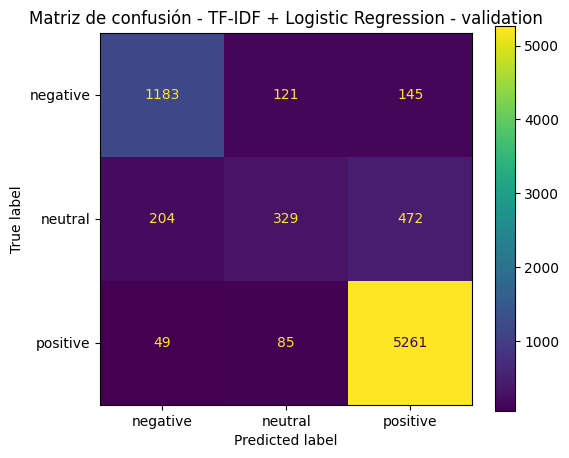

TF-IDF + Logistic Regression - test
Accuracy:    0.8670
Macro F1:    0.7178
Weighted F1: 0.8518

Classification report:
              precision    recall  f1-score   support

    negative     0.8184    0.8207    0.8196      1428
     neutral     0.5752    0.3024    0.3964       936
    positive     0.9028    0.9748    0.9374      5517

    accuracy                         0.8670      7881
   macro avg     0.7655    0.6993    0.7178      7881
weighted avg     0.8486    0.8670    0.8518      7881



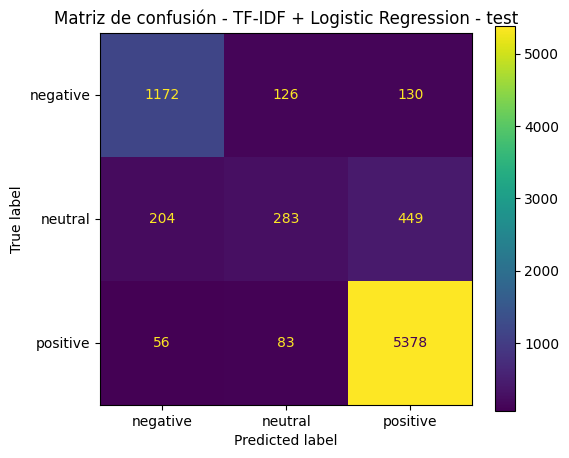

In [28]:
# ============================================================
# 19. TF-IDF + Regresión Logística
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_logreg = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.90,
                max_features=100_000,
                sublinear_tf=True
            )
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                solver="saga",
                multi_class="multinomial",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

tfidf_logreg.fit(X_train, y_train)

val_pred_tfidf = tfidf_logreg.predict(X_val)
test_pred_tfidf = tfidf_logreg.predict(X_test)

tfidf_val_metrics, tfidf_val_report, tfidf_val_cm = evaluate_predictions(
    y_val,
    val_pred_tfidf,
    model_name="TF-IDF + Logistic Regression",
    split_name="validation"
)

tfidf_test_metrics, tfidf_test_report, tfidf_test_cm = evaluate_predictions(
    y_test,
    test_pred_tfidf,
    model_name="TF-IDF + Logistic Regression",
    split_name="test"
)

TF-IDF + Logistic Regression Balanced - validation
Accuracy:    0.7913
Macro F1:    0.7088
Weighted F1: 0.8148

Classification report:
              precision    recall  f1-score   support

    negative     0.8857    0.6259    0.7335      1449
     neutral     0.3673    0.7682    0.4969      1005
    positive     0.9596    0.8400    0.8958      5395

    accuracy                         0.7913      7849
   macro avg     0.7375    0.7447    0.7088      7849
weighted avg     0.8701    0.7913    0.8148      7849



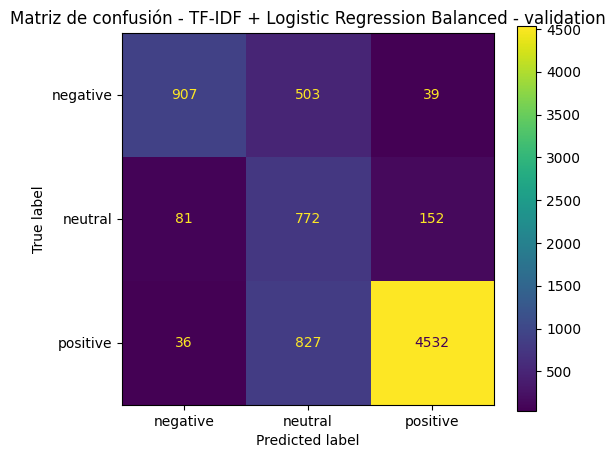

TF-IDF + Logistic Regression Balanced - test
Accuracy:    0.8066
Macro F1:    0.7204
Weighted F1: 0.8291

Classification report:
              precision    recall  f1-score   support

    negative     0.8998    0.6541    0.7575      1428
     neutral     0.3698    0.7724    0.5002       936
    positive     0.9615    0.8519    0.9034      5517

    accuracy                         0.8066      7881
   macro avg     0.7437    0.7595    0.7204      7881
weighted avg     0.8801    0.8066    0.8291      7881



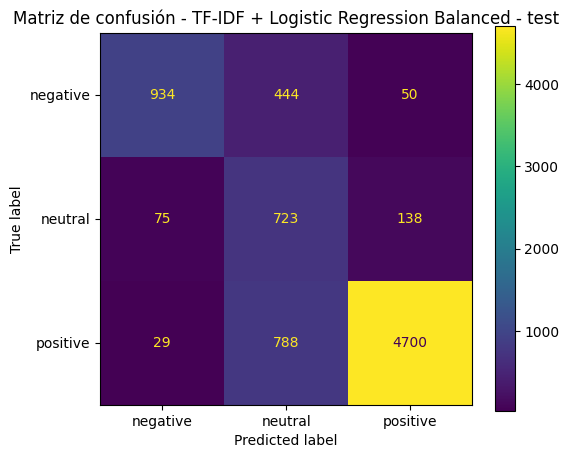

In [29]:
# ============================================================
# 20. TF-IDF + Regresión Logística balanceada
# ============================================================

tfidf_logreg_balanced = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.90,
                max_features=100_000,
                sublinear_tf=True
            )
        ),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                solver="saga",
                multi_class="multinomial",
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

tfidf_logreg_balanced.fit(X_train, y_train)

val_pred_tfidf_balanced = tfidf_logreg_balanced.predict(X_val)
test_pred_tfidf_balanced = tfidf_logreg_balanced.predict(X_test)

tfidf_balanced_val_metrics, tfidf_balanced_val_report, tfidf_balanced_val_cm = evaluate_predictions(
    y_val,
    val_pred_tfidf_balanced,
    model_name="TF-IDF + Logistic Regression Balanced",
    split_name="validation"
)

tfidf_balanced_test_metrics, tfidf_balanced_test_report, tfidf_balanced_test_cm = evaluate_predictions(
    y_test,
    test_pred_tfidf_balanced,
    model_name="TF-IDF + Logistic Regression Balanced",
    split_name="test"
)

,model_name,split,accuracy,macro_f1,weighted_f1
0,TF-IDF + Logistic Regression Balanced,test,0.806624,0.720362,0.829082
1,TF-IDF + Logistic Regression,test,0.867022,0.717788,0.851811
2,Majority Baseline,test,0.700038,0.274519,0.576520
3,TF-IDF + Logistic Regression,validation,0.862912,0.726919,0.847666
4,TF-IDF + Logistic Regression Balanced,validation,0.791311,0.708765,0.814792
5,Majority Baseline,validation,0.687349,0.271570,0.559989


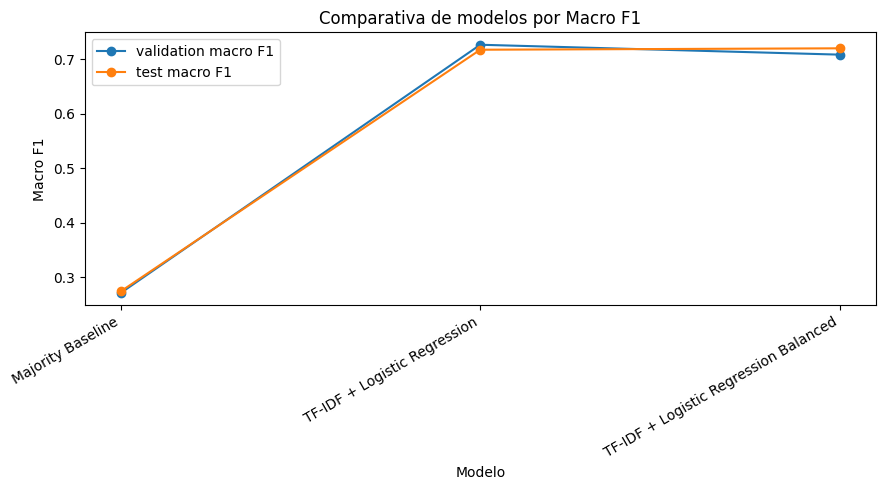

In [30]:
# ============================================================
# 21. Comparativa de modelos
# ============================================================

metrics_rows = [
    majority_val_metrics,
    majority_test_metrics,
    tfidf_val_metrics,
    tfidf_test_metrics,
    tfidf_balanced_val_metrics,
    tfidf_balanced_test_metrics,
]

metrics_df = pd.DataFrame(metrics_rows)

display(
    metrics_df
    .sort_values(["split", "macro_f1"], ascending=[True, False])
    .reset_index(drop=True)
)

plt.figure(figsize=(9, 5))

for split_name in ["validation", "test"]:
    subset = metrics_df[metrics_df["split"] == split_name]
    plt.plot(
        subset["model_name"],
        subset["macro_f1"],
        marker="o",
        label=f"{split_name} macro F1"
    )

plt.title("Comparativa de modelos por Macro F1")
plt.xlabel("Modelo")
plt.ylabel("Macro F1")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# 22. Guardar métricas
# ============================================================

classic_models_dir = OUTPUT_DIR / "classic_models"
classic_models_dir.mkdir(parents=True, exist_ok=True)

metrics_output_path = classic_models_dir / "classic_model_metrics.json"

all_metrics = {
    "majority_baseline": {
        "validation": {
            "metrics": majority_val_metrics,
            "classification_report": majority_val_report,
            "confusion_matrix": majority_val_cm,
        },
        "test": {
            "metrics": majority_test_metrics,
            "classification_report": majority_test_report,
            "confusion_matrix": majority_test_cm,
        },
    },
    "tfidf_logistic_regression": {
        "validation": {
            "metrics": tfidf_val_metrics,
            "classification_report": tfidf_val_report,
            "confusion_matrix": tfidf_val_cm,
        },
        "test": {
            "metrics": tfidf_test_metrics,
            "classification_report": tfidf_test_report,
            "confusion_matrix": tfidf_test_cm,
        },
    },
    "tfidf_logistic_regression_balanced": {
        "validation": {
            "metrics": tfidf_balanced_val_metrics,
            "classification_report": tfidf_balanced_val_report,
            "confusion_matrix": tfidf_balanced_val_cm,
        },
        "test": {
            "metrics": tfidf_balanced_test_metrics,
            "classification_report": tfidf_balanced_test_report,
            "confusion_matrix": tfidf_balanced_test_cm,
        },
    },
}

with metrics_output_path.open("w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2, ensure_ascii=False)

print("Métricas guardadas en:")
print(metrics_output_path)

Métricas guardadas en:
/content/hidden_gems_ai/outputs/sentiment_review/classic_models/classic_model_metrics.json


In [32]:
# ============================================================
# 23. Guardar mejor modelo clásico
# ============================================================

import joblib

# Elegimos el mejor por macro F1 en validation
validation_metrics_df = metrics_df[metrics_df["split"] == "validation"].copy()
best_row = validation_metrics_df.sort_values("macro_f1", ascending=False).iloc[0]

best_model_name = best_row["model_name"]

if best_model_name == "TF-IDF + Logistic Regression":
    best_classic_model = tfidf_logreg
elif best_model_name == "TF-IDF + Logistic Regression Balanced":
    best_classic_model = tfidf_logreg_balanced
else:
    best_classic_model = majority_baseline

best_model_path = classic_models_dir / "best_classic_sentiment_model.joblib"

joblib.dump(best_classic_model, best_model_path)

print("Mejor modelo clásico según validation macro F1:")
print(best_model_name)

print("\nModelo guardado en:")
print(best_model_path)

Mejor modelo clásico según validation macro F1:
TF-IDF + Logistic Regression

Modelo guardado en:
/content/hidden_gems_ai/outputs/sentiment_review/classic_models/best_classic_sentiment_model.joblib


In [33]:
# ============================================================
# 24. Probar predicciones manuales
# ============================================================

manual_examples = [
    "The burger was amazing, juicy and perfectly cooked.",
    "The food was okay, nothing special, but the service was fine.",
    "The pizza was cold, dry and honestly disappointing.",
    "Great atmosphere, but the pasta was bland and overpriced.",
    "I loved the tacos and the homemade salsa was fantastic."
]

manual_preds = best_classic_model.predict(manual_examples)

manual_results = pd.DataFrame({
    "text": manual_examples,
    "predicted_sentiment": manual_preds
})

display(manual_results)

,text,predicted_sentiment
0,"The burger was amazing, juicy and perfectly cooked.",positive
1,"The food was okay, nothing special, but the service was fine.",neutral
2,"The pizza was cold, dry and honestly disappointing.",negative
3,"Great atmosphere, but the pasta was bland and overpriced.",negative
4,I loved the tacos and the homemade salsa was fantastic.,positive


## 3. Análisis de errores del modelo clásico

Antes de entrenar un modelo transformer, se analiza el comportamiento del mejor modelo clásico.

El objetivo es entender:

- qué clases confunde con más frecuencia;
- qué ocurre con la clase neutral;
- qué ejemplos son ambiguos;
- qué errores pueden deberse a la etiqueta débil derivada del rating;
- qué limitaciones tendrá este modelo como módulo auxiliar dentro de Hidden Gems.

Este análisis es importante porque el rating de Yelp no siempre representa el sentimiento real del texto ni el sentimiento asociado a un plato concreto.

In [34]:
# ============================================================
# 25. Obtener predicciones del mejor modelo clásico
# ============================================================

best_val_pred = best_classic_model.predict(X_val)
best_test_pred = best_classic_model.predict(X_test)

val_errors_df = val_df.copy()
val_errors_df["predicted_sentiment"] = best_val_pred
val_errors_df["is_correct"] = (
    val_errors_df["sentiment_label"] == val_errors_df["predicted_sentiment"]
)

test_errors_df = test_df.copy()
test_errors_df["predicted_sentiment"] = best_test_pred
test_errors_df["is_correct"] = (
    test_errors_df["sentiment_label"] == test_errors_df["predicted_sentiment"]
)

print("Validation accuracy manual:", val_errors_df["is_correct"].mean())
print("Test accuracy manual:", test_errors_df["is_correct"].mean())

display(test_errors_df.head(3))

Validation accuracy manual: 0.8629124729264874
Test accuracy manual: 0.8670219515289938


,review_id,business_id,text,text_length_chars,rating_value,sentiment_label,language,review_date,split,model_text,predicted_sentiment,is_correct
54,Lk21QNbrI_e3nf0GvWSPww,sLgnx_WFCjEoPsS6NwU70Q,Our family returned for breakfast again this weekend and the food and service was again impeccable ... Highly recommend,119,5.0,positive,en,2014-10-27 16:31:37,test,Our family returned for breakfast again this weekend and the food and service was again impeccable ... Highly recommend,positive,True
62,RGV9GWhAAfAAlYyd4vho7g,3ZynJ94VpIdDlaArmEp2Rg,"A couple friends and I stopped by for some late night milkshakes and found ourselves at More Than Just Ice Cream. Well, we just got ice cream...not fully taking advantage of what the name implies, but maybe next time. 3 milkshakes: 1 coffee, 1 ch...",778,3.0,neutral,en,2013-10-03 16:24:30,test,"A couple friends and I stopped by for some late night milkshakes and found ourselves at More Than Just Ice Cream. Well, we just got ice cream...not fully taking advantage of what the name implies, but maybe next time. 3 milkshakes: 1 coffee, 1 ch...",positive,False
75,PPgbLBvi34A6m7bKJfTwhw,GyC36Pn0Q1-qHnqXys6yFg,Service and management terrible... After messing up all 4 of our orders the waiter got mad and started cursing... The manager offered our drinks to be free.. What a mess. The food was cold and nasty didn't even eat half of it and waited over an h...,323,1.0,negative,en,2013-12-07 13:17:13,test,Service and management terrible... After messing up all 4 of our orders the waiter got mad and started cursing... The manager offered our drinks to be free.. What a mess. The food was cold and nasty didn't even eat half of it and waited over an h...,negative,True


In [35]:
# ============================================================
# 26. Errores por clase real y predicha
# ============================================================

error_summary = (
    test_errors_df
    .groupby(["sentiment_label", "predicted_sentiment"])
    .size()
    .reset_index(name="count")
    .sort_values(["sentiment_label", "count"], ascending=[True, False])
)

display(error_summary)

only_errors = test_errors_df[~test_errors_df["is_correct"]].copy()

print("Total errores en test:", len(only_errors))
print("Porcentaje de errores:", round(len(only_errors) / len(test_errors_df) * 100, 2), "%")

error_type_summary = (
    only_errors
    .groupby(["sentiment_label", "predicted_sentiment"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(error_type_summary)

,sentiment_label,predicted_sentiment,count
0,negative,negative,1172
2,negative,positive,130
1,negative,neutral,126
5,neutral,positive,449
4,neutral,neutral,283
3,neutral,negative,204
8,positive,positive,5378
7,positive,neutral,83
6,positive,negative,56


Total errores en test: 1048
Porcentaje de errores: 13.3 %


,sentiment_label,predicted_sentiment,count
3,neutral,positive,449
2,neutral,negative,204
1,negative,positive,130
0,negative,neutral,126
5,positive,neutral,83
4,positive,negative,56


In [36]:
# ============================================================
# 27. Ejemplos de errores frecuentes
# ============================================================

def show_error_examples(errors_df, true_label, predicted_label, n=5, max_chars=1200):
    subset = errors_df[
        (errors_df["sentiment_label"] == true_label)
        & (errors_df["predicted_sentiment"] == predicted_label)
    ].copy()

    print("=" * 100)
    print(f"TRUE = {true_label} | PRED = {predicted_label} | total = {len(subset)}")
    print("=" * 100)

    if subset.empty:
        print("No hay ejemplos para este tipo de error.")
        return

    sample = subset.sample(
        n=min(n, len(subset)),
        random_state=RANDOM_STATE
    )

    for i, row in enumerate(sample.itertuples(), start=1):
        print(f"\nEjemplo {i}")
        print(f"Rating: {getattr(row, 'rating_value', None)}")
        print(f"Real: {row.sentiment_label}")
        print(f"Predicho: {row.predicted_sentiment}")
        print(f"Texto:\n{row.text[:max_chars]}")
        print("-" * 100)


# Errores más interesantes
show_error_examples(test_errors_df, "neutral", "positive", n=5)
show_error_examples(test_errors_df, "neutral", "negative", n=5)
show_error_examples(test_errors_df, "negative", "positive", n=5)
show_error_examples(test_errors_df, "positive", "negative", n=5)

TRUE = neutral | PRED = positive | total = 449

Ejemplo 1
Rating: 3.0
Real: neutral
Predicho: positive
Texto:
Gators is a staple in our band viewing and listening options. We recently visited and saw a new band called Flyte Band Tampa. They definitely made the night great. They played a fun mix of songs that you could dance to and did it well. We'd definitely come back to see them again. It's too bad that the food seems to be only fair. It used to be better but has been slipping on taste and quality as of late. I'm not saying it's bad but rather it has slipped to being simply "bar fare", perhaps it can rise again. We shall see.
----------------------------------------------------------------------------------------------------

Ejemplo 2
Rating: 3.0
Real: neutral
Predicho: positive
Texto:
If you have a Travelzoo deal for this restaurant, do not fear! I was hesitant to go based on the other reviews, but we were pleasantly surprised. The bread with dipping sauces was delicious. calamari 

In [37]:
# ============================================================
# 28. Análisis de confianza con probabilidades
# ============================================================

if hasattr(best_classic_model, "predict_proba"):
    test_proba = best_classic_model.predict_proba(X_test)
    class_names = list(best_classic_model.classes_)

    proba_df = pd.DataFrame(
        test_proba,
        columns=[f"proba_{cls}" for cls in class_names],
        index=test_df.index
    )

    test_confidence_df = pd.concat(
        [test_errors_df.reset_index(drop=True), proba_df.reset_index(drop=True)],
        axis=1
    )

    proba_cols = [f"proba_{cls}" for cls in class_names]

    test_confidence_df["prediction_confidence"] = test_confidence_df[proba_cols].max(axis=1)

    print("Confianza media por acierto/error:")
    display(
        test_confidence_df
        .groupby("is_correct")["prediction_confidence"]
        .agg(["count", "mean", "median", "min", "max"])
        .round(4)
    )

    print("\nErrores con mayor confianza del modelo:")
    high_conf_errors = (
        test_confidence_df[~test_confidence_df["is_correct"]]
        .sort_values("prediction_confidence", ascending=False)
        .head(10)
    )

    display(
        high_conf_errors[
            [
                "sentiment_label",
                "predicted_sentiment",
                "rating_value",
                "prediction_confidence",
                "text"
            ]
        ]
    )
else:
    print("El modelo no permite predict_proba.")

Confianza media por acierto/error:


,count,mean,median,min,max
is_correct,,,,,
False,1048,0.6140,0.5830,0.3384,0.9907
True,6833,0.8681,0.9319,0.3445,0.9999



Errores con mayor confianza del modelo:


,sentiment_label,predicted_sentiment,rating_value,prediction_confidence,text
1722,neutral,positive,3.0,0.990717,"Food was excellent, but service lacked...several choices and everything tasted great. Highly recommend the Shrimp Carbonara PoBoy, large enough to split. Bread was fresh and so good."
4339,neutral,positive,3.0,0.988522,"Love the many choices of burgers here and always so tasty. The service always on their game and the bartender, Carlos is amazing!!!!!! Great spot for lunch or a bite before the Pacer game. One of my favs - and the sides are to die for !!!!!"
5698,neutral,positive,3.0,0.986048,"Great spot for breakfast , awesome grits , egg's and meats specials,lot's of choices on the menu,just really good food."
5538,neutral,positive,3.0,0.985879,"A really nice coffee shop with excellent iced coffee, well-crafted coffee drinks (I had a really good Americano) and a great selection of pastries. There is free wi-fi service and comfortable working space. I'd love to come back and see what else..."
6245,neutral,positive,3.0,0.985523,"The place is small, with bright decor, yet feels intimate and authentic. The owner was very welcoming and struck up a nice conversation with us food and business. I had three pupusas. A cheese, chicharron, and revueltas with a Horchata Salvadoreñ..."
4709,neutral,positive,3.0,0.984393,"Cool casual ambience, great for dinner with friends. Definitely a restaurant worth visiting in St. Louis. Ordered the Duke! Shredded bbq chicken and amazing corn salsa. I usually don't eat calzones because you usually just get a bunch of bread. L..."
5556,neutral,positive,3.0,0.977321,Cool Russian inspired food and unique beers brewed IN HOUSE. Just found out they offer brewery tours now; which I'll be looking into. Staff is chill and an interesting group of down-to-earth guys who started this establishment from ground up. Liv...
2928,neutral,positive,3.0,0.971245,The bbq beans were very delicious. The Tri-Pi with the chimichurri was seasoned well.
294,neutral,positive,3.0,0.964884,"One of the best places on Washington Avenue to sit outside and relax. A very relaxing atmosphere both inside and out, with service to match. We enjoyed both outside for people watching and inside for the fireplace and black and white movies on th..."
5745,neutral,negative,3.0,0.963530,"Disappointed tonight.... Fries were soggy, the wait staff was rude...no side dip was in my order... They were out of hamburger meat!!!wTH?'! Is this place trying to go downhill? My first really bad experience with them and most likely my last..."


In [38]:
# ============================================================
# 29. Guardar análisis de errores
# ============================================================

error_analysis_dir = OUTPUT_DIR / "error_analysis"
error_analysis_dir.mkdir(parents=True, exist_ok=True)

test_errors_path = error_analysis_dir / "classic_model_test_predictions.parquet"
error_summary_path = error_analysis_dir / "classic_model_error_summary.json"

test_errors_df.to_parquet(test_errors_path, index=False)

error_analysis_summary = {
    "best_classic_model": str(best_model_name),
    "test_total": int(len(test_errors_df)),
    "test_correct": int(test_errors_df["is_correct"].sum()),
    "test_errors": int((~test_errors_df["is_correct"]).sum()),
    "test_accuracy_manual": float(test_errors_df["is_correct"].mean()),
    "error_types": [
        {
            "true_label": str(row.sentiment_label),
            "predicted_label": str(row.predicted_sentiment),
            "count": int(row.count),
        }
        for row in error_type_summary.itertuples(index=False)
    ],
}

with error_summary_path.open("w", encoding="utf-8") as f:
    json.dump(error_analysis_summary, f, indent=2, ensure_ascii=False)

print("Predicciones test guardadas en:")
print(test_errors_path)

print("\nResumen de errores guardado en:")
print(error_summary_path)

Predicciones test guardadas en:
/content/hidden_gems_ai/outputs/sentiment_review/error_analysis/classic_model_test_predictions.parquet

Resumen de errores guardado en:
/content/hidden_gems_ai/outputs/sentiment_review/error_analysis/classic_model_error_summary.json


## Conclusiones preliminares del modelo clásico

El modelo TF-IDF + Regresión Logística supera ampliamente al baseline mayoritario, lo que confirma que el texto de las reseñas contiene señales útiles para estimar sentimiento general.

Sin embargo, el análisis muestra varias limitaciones:

- la clase `positive` domina el corpus;
- la clase `neutral` es la más ambigua;
- algunas reseñas mezclan opiniones sobre comida, servicio, precio y ambiente;
- el rating funciona como etiqueta débil, pero no como verdad perfecta;
- este modelo predice sentimiento general de review, no sentimiento específico por plato.

Por tanto, este modelo se utilizará como baseline y módulo auxiliar, pero Hidden Gems necesitará posteriormente un análisis más fino por mención de plato.

## Cierre del Notebook 01

En este notebook se ha construido una primera línea base sólida para clasificación de sentimiento general sobre reviews gastronómicas de Yelp.

El modelo mayoritario demuestra que la accuracy no es suficiente como métrica principal, ya que obtiene un resultado aparentemente alto debido al desbalance de clases, pero falla completamente en las clases `negative` y `neutral`.

El modelo TF-IDF + Regresión Logística mejora claramente el rendimiento y queda seleccionado como mejor modelo clásico según el rendimiento en validación. Además, las predicciones manuales muestran un comportamiento coherente en ejemplos simples.

El análisis de errores revela que la clase `neutral` es la más problemática. Esto confirma que las etiquetas derivadas del rating deben tratarse como etiquetas débiles, ya que muchas reviews de 3 estrellas contienen opiniones mixtas o valoraciones positivas/negativas sobre aspectos concretos.

Este modelo se considera un baseline fuerte y un módulo auxiliar. El siguiente paso será entrenar un modelo transformer y comparar si aporta una mejora suficiente respecto al enfoque clásico.